In [2]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

In [3]:
# ==========================================================
# Dense Coding using Bell State
# ==========================================================
qc = QuantumCircuit(2,2)

# ----------------------------------------------------------
# Bell State Preparation
# ----------------------------------------------------------

qc.h(0)
qc.cx(0,1)
qc.barrier()
message=11
# ----------------------------------------------------------
# Alice Encoding
# ----------------------------------------------------------

if message == "00":
    pass

elif message == "01":
    qc.x(0)

elif message == "10":
    qc.z(0)

elif message == "11":
    qc.x(0)
    qc.z(0)
qc.barrier()
# ----------------------------------------------------------
# Bob Decoding
# ----------------------------------------------------------

qc.cx(0,1)
qc.h(0)
qc.barrier()
# ----------------------------------------------------------
# Measurement
# ----------------------------------------------------------
message = "10"      # 00,01,10,11

qc.measure([0,1],[0,1])

print(qc.draw())

     ┌───┐      ░  ░      ┌───┐ ░ ┌─┐   
q_0: ┤ H ├──■───░──░───■──┤ H ├─░─┤M├───
     └───┘┌─┴─┐ ░  ░ ┌─┴─┐└───┘ ░ └╥┘┌─┐
q_1: ─────┤ X ├─░──░─┤ X ├──────░──╫─┤M├
          └───┘ ░  ░ └───┘      ░  ║ └╥┘
c: 2/══════════════════════════════╩══╩═
                                   0  1 


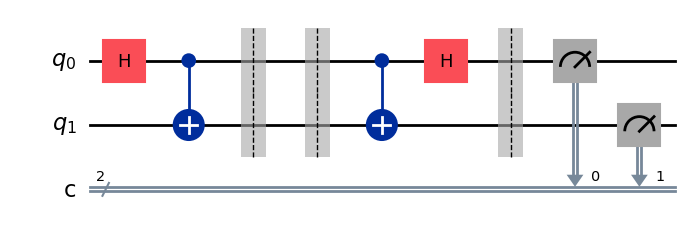

In [4]:
qc.draw(output="mpl")

In [5]:
print(qc.depth())

5


{'00': 1024, '01': 0, '10': 0, '11': 0}


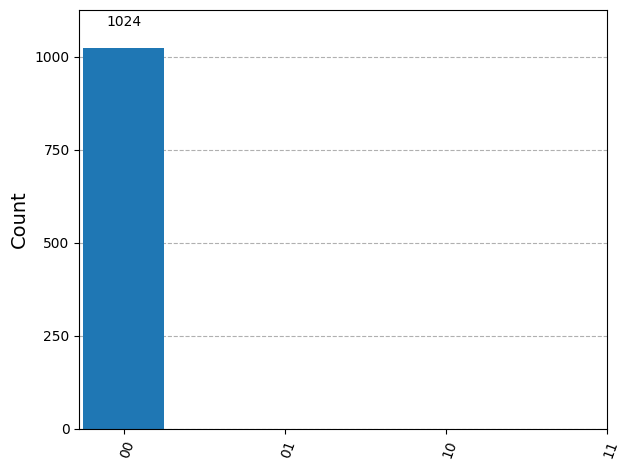

In [6]:
simulator = Aer.get_backend('qasm_simulator')

result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

# Add missing states with zero counts
all_states = ['00', '01', '10', '11']

counts_complete = {state: counts.get(state, 0) for state in all_states}

print(counts_complete)

plot_histogram(counts_complete)